In [ ]:
# 실습 준비 — 03주차 2차원 데이터 정리 — 지표 계산·시각화
# 이 셀을 먼저 한 번 실행하세요. 데이터가 없으면 아래 셀들이 전부 실패합니다.
import os, pathlib, urllib.request

BASE = "https://raw.githubusercontent.com/aprilslab/statistics-lab/main/data/"
FILES = ["ch2_scores_em.csv", "ch3_anscombe.npy"]

pathlib.Path("data").mkdir(exist_ok=True)
for name in FILES:
    for dest in (pathlib.Path(name), pathlib.Path("data") / name):
        if not dest.exists():
            urllib.request.urlretrieve(BASE + name, dest)

# '../data/x.csv' 로 읽는 노트북 대응 — 상위 폴더에도 같은 data/ 를 걸어둔다.
# 절대경로(/data)로 박으면 cwd 가 /content 가 아닐 때 깨지므로 상대경로로 건다.
try:
    parent = pathlib.Path("..") / "data"
    if not parent.exists():
        os.symlink(pathlib.Path("data").resolve(), parent)
except OSError:
    pass

print("준비 완료:", ", ".join(FILES) if FILES else "(내려받을 데이터 없음)")


# 2차원 데이터의 정리 (부제: 데이터의 상관성 파악)

In [ ]:
# 우리는 colab에 파일을 올려놓고 데이터를 읽어 올 것이기 때문에 google drive를 먼저 연결해줍니다.
# 좌측의 폴더 버튼을 누르세요.
# 상단의 구글 마크가 있는 폴더 버튼을 눌러서 마운트 해주세요.
# 마운트 버튼을 누르면 코랩을 연결하는 코드 셀이 생성됩니다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 데이터에 편하게 접근하기 위해 working directory를 data 폴더로 지정해줍니다.
# 본인이 코드를 받은 폴더 내부에 있는 data 폴더 우클릭하여 '경로복사'를 수행합니다.
# 복사한 경로를 work_dir에 붙여넣고 실행합니다.
import os
work_dir = '/content/drive/MyDrive/데이터통계분석/source/data'
os.chdir(work_dir)

In [3]:
!pwd

/content/drive/MyDrive/데이터통계분석/source/data


In [4]:
# 현재 폴더에 있는 파일 목록을 출력해봅니다.
!ls

ch10_access.csv   ch11_potato.csv	 ch12_scores_reg.csv  ch3_anscombe.npy
ch10_enquete.csv  ch11_training_ind.csv  ch1_sport_test.csv   ch4_scores400.csv
ch11_ad.csv	  ch11_training_rel.csv  ch2_scores_em.csv    Untitled.ipynb


## 두 데이터 사이의 관계를 나타내는 지표

In [5]:
# 2차원 데이터로 정리하면 '수학점수가 높은 학생의 영어점수도 높은가' 같은 데이터의 상관성을 파악할 수 있습니다.
# 2차원 데이터를 정리하는 방법 역시 데이터를 요약하는 지표와 시각화하는 그래프 작성 방법으로 나눕니다.

# 다음과 같은 nameing convention을 가진 패키지를 import 합니다.
import numpy as np
import pandas as pd

%precision 3
pd.set_option('display.precision', 3)

In [6]:
# 이번장에서도 챕터2의 데이터를 사용합니다.
# 이번에는 영어점수 뿐만 아니라 수학 점수도 사용할 것입니다.

# pd.read_csv로 'ch2_scores_em.csv' 데이터를 읽어줍니다. index_col='student number' 입니다.
df = pd.read_csv('ch2_scores_em.csv', index_col='student number')

# df.head()로 데이터를 출력해봅니다.
df.head()

,english,mathematics
student number,,
1,42,65
2,69,80
3,56,63
4,41,63
5,57,76


In [7]:

# DataFrame에서 df['column이름']을 입력하면 해당 컬럼을 Series로 리턴합니다.
# 'english', 'mathematics' 열의 Series를 입력받아 numpy array를 생성하고, 10개의 행을 index slice 해줍니다.
en_scores = np.array(df['english'])[:10]
ma_scores = np.array(df['mathematics'])[:10]

# index 생성은 index=pd.Index({lables list}, name='{인덱스 이름}') << 형식으로 생성해줍니다. rows의 갯수와 같아야합니다.
# 레이블은 ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'] 로 이름은 'student' 인덱스를 생성합니다.

scores_df = pd.DataFrame({'english':en_scores, 'mathematics':ma_scores}, index=pd.Index(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'], name='student'))

# DataFrame을 전체 출력해봅시다.
scores_df

,english,mathematics
student,,
A,42,65
B,69,80
C,56,63
D,41,63
E,57,76
F,48,60
G,65,81
H,49,66
I,65,78


### * 참고: pandas DataFrame에서 index를 지정하면 무엇이 다를까?

#### * Index Slicing

In [8]:
# 레이블로 index slicing시 해당 '인덱스을 포함'한 행까지 보여줍니다.
scores_df[:'C'] # 'A', 'B', 'C'

,english,mathematics
student,,
A,42,65
B,69,80
C,56,63


In [9]:
# B ~ D까지 index slice 해봅시다.
scores_df['B':'D']

,english,mathematics
student,,
B,69,80
C,56,63
D,41,63


In [10]:
# 숫자를 통한 index slicing시 해당 '인덱스 이전까지'의 행들을 보여줍니다.
scores_df[:3] # 0, 1, 2

,english,mathematics
student,,
A,42,65
B,69,80
C,56,63


In [11]:
# 1 ~ 4까지 index slice 해봅시다.
scores_df[1:5]

,english,mathematics
student,,
B,69,80
C,56,63
D,41,63
E,57,76


#### * 레이블을 통한 데이터 접근: df.loc

In [12]:
# df[label]은 열을 가져옴.
scores_df['english']

,english
student,
A,42
B,69
C,56
D,41
E,57
F,48
G,65
H,49
I,65


In [13]:
# mathematics 열을 가져와 봅시다.
scores_df['mathematics']

,mathematics
student,
A,65
B,80
C,63
D,63
E,76
F,60
G,81
H,66
I,78


In [14]:
# df.loc[label]은 행(Series)을 가져옴
scores_df.loc['A']

,A
english,42
mathematics,65


In [15]:
# 'B' 행을 가져와 봅시다.
scores_df.loc['B']

,B
english,69
mathematics,80


In [16]:
# List of labels
# df.loc[[레이블 리스트]]
# DataFrame을 리턴합니다.
scores_df.loc[['A','C','E']]

,english,mathematics
student,,
A,42,65
C,56,63
E,57,76


In [17]:
# 'B', 'C', 'D' 행을 가져와 봅시다.
scores_df.loc[['B','C','D']]

,english,mathematics
student,,
B,69,80
C,56,63
D,41,63


In [18]:
# Single label for row and column
# df.loc['row','col']
# Scalar를 리턴합니다.
scores_df.loc['A','english']

np.int64(42)

In [19]:
# 'B'행의 'mathematics' 점수를 가져와 봅시다.
scores_df.loc['B','mathematics']

np.int64(80)

In [20]:
# A list or array of labels
# '마지막 레이블을 포함'하여 인덱스 슬라이싱을 합니다.
scores_df.loc['B':'C']

,english,mathematics
student,,
B,69,80
C,56,63


In [21]:
# 'A' ~ 'D'행까지 가져와봅시다.
scores_df.loc['A':'D']

,english,mathematics
student,,
A,42,65
B,69,80
C,56,63
D,41,63


In [ ]:
# Slice with labels for row and single label for column
# '마지막 레이블을 포함'하여 인덱스 슬라이싱을 합니다.
scores_df.loc['B':'C','english']

In [23]:
# 'A' ~ 'D' 행 까지의 mathematics 열을 가져와 봅시다.
scores_df.loc['A':'D', 'mathematics']

,mathematics
student,
A,65
B,80
C,63
D,63


#### * 정수를 통한 데이터 접근: df.**iloc**

In [24]:
# An integer
# df.iloc[정수]
# Series를 리턴합니다.
scores_df.iloc[0]

,A
english,42
mathematics,65


In [25]:
# 1행을 가져와 봅시다.
scores_df.iloc[1]

,B
english,69
mathematics,80


In [26]:
# A list or array of integers
# df.iloc[[정수 리스트]]
# DataFrame를 리턴합니다.
scores_df.iloc[[0, 2, 4]]

,english,mathematics
student,,
A,42,65
C,56,63
E,57,76


In [27]:
# 3,4,5 행을 가져와 봅시다.
scores_df.iloc[[3,4,5]]

,english,mathematics
student,,
D,41,63
E,57,76
F,48,60


In [28]:
# A slice object with ints
# '마지막 정수를 미포함'하여 인덱스 슬라이싱을 합니다.
scores_df.iloc[:3]

,english,mathematics
student,,
A,42,65
B,69,80
C,56,63


In [29]:
# 4행까지의 데이터를 가져와 봅시다.
scores_df.iloc[:5]

,english,mathematics
student,,
A,42,65
B,69,80
C,56,63
D,41,63
E,57,76


In [30]:
# Slice with ints for row and single int for column
# '마지막 정수를 미포함'하여 인덱스 슬라이싱을 합니다.
scores_df.iloc[1:2, 0]

,english
student,
B,69


In [31]:
# 처음부터 3행까지의 데이터의 1번째 컬럼을 가져와 봅시다.
scores_df.iloc[:4, 1]

,mathematics
student,
A,65
B,80
C,63
D,63


#### * 정수를 인덱스로 삼았을때? → 레이블 기반 인덱스 슬라이싱이 아니라 정수 기반 인덱스 슬라이싱이 된다!
레이블로 접근을 원하면 명시적으로 df.loc을 사용

In [33]:
df.head()

,english,mathematics
student number,,
1,42,65
2,69,80
3,56,63
4,41,63
5,57,76


In [34]:
# 3번 인덱스 바로 전인 2번행까지만 포함한다.
df[:3] # 0, 1, 2

,english,mathematics
student number,,
1,42,65
2,69,80
3,56,63


In [35]:
# label이 3인 행까지 포함한다.
df.loc[:3]

,english,mathematics
student number,,
1,42,65
2,69,80
3,56,63


In [36]:
# custom index를 해제하고 기본 인덱스를 사용하면 명확히 볼 수 있다.
df.reset_index()[:3] # 0, 1, 2

,student number,english,mathematics
0,1,42,65
1,2,69,80
2,3,56,63


In [37]:
# custom index를 해제하면 기본 인덱스가 정수로 자동으로 매겨진다.
# 기본 인덱스가 정수 레이블로 취급되어 0,1,2,3이 포함되기 때문에 4개의 행이 보인다.
df.reset_index().loc[:3]

,student number,english,mathematics
0,1,42,65
1,2,69,80
2,3,56,63
3,4,41,63


### 공분산(共分散)
'co-var-i-ance' <br>
코바리언스

In [ ]:
# 분산의 수식 기호는 다음과 같았습니다.
# 자기 자신의 편차를 곱해서 편차의 제곱을 만든 뒤 평균을 만들었습니다.
from IPython.display import display, Math
display(Math(r"{S}^2 = \frac{1}{n}{\sum_{i=1}^{n} ({x_i - \bar{x}})^2}"))

<IPython.core.display.Math object>

In [ ]:
# 공분산의 수식 기호는 다음과 같습니다.
# 자기 자기 외에 관계성을 구하고 싶은 대상과 본인의 편차를 곱한 뒤 평균을 만듭니다.
display(Math(r"S_{xy} = \frac{1}{n}{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}"))

<IPython.core.display.Math object>

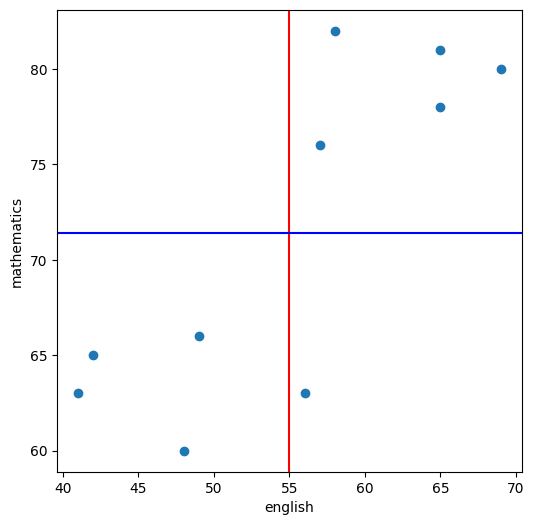

In [38]:
# X, Y라는 특성이 있을 때, X가 높을 수록 Y도 높은 경향이 있다 → 양의 상관관계
# X, Y라는 특성이 있을 때, X가 높을 수록 Y가 낮은 경향이 있다 → 음의 상관관계
# X, Y라는 특성이 있을 때, 양의 상관관계도 아니고 음의 상관관계도 아니다 → 무상관

# 영어와 수학점수가 어떻게 분포되어 있는지 살표봅시다.
# 빨간 선은 영어점수의 평균, 파란선은 수학점수의 평균입니다.
# 점수의 분포를 살펴보면 영어점수와 수학점수는 양의 상관관계에 있다고 말할 수 있습니다.
# 이처럼, 상관관계가 있다고 생각되는 데이터의 관계성을 수치화할 때 사용하는 지표가 공분산(covariance)입니다.

# 시각화를 할때 사용하는 패키지를 import 합니다.
import matplotlib.pyplot as plt

# 그림판 만들기
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

# 산점도 그리기
ax.scatter(en_scores, ma_scores)

# 평균 선 그어주기
ax.axvline(en_scores.mean(), color='red')
ax.axhline(ma_scores.mean(), color='blue')

ax.set_xlabel('english')
ax.set_ylabel('mathematics')
plt.show()

In [40]:
# DataFrame을 사용해서 수치를 정리해봅시다.
summary_df = scores_df.copy()
summary_df['english_deviation'] = en_scores - en_scores.mean()
summary_df['mathematics_deviation'] = ma_scores - ma_scores.mean()
summary_df['product of deviations'] = summary_df['english_deviation'] * summary_df['mathematics_deviation']
summary_df

,english,mathematics,english_deviation,mathematics_deviation,product of deviations
student,,,,,
A,42,65,-13.0,-6.4,83.2
B,69,80,14.0,8.6,120.4
C,56,63,1.0,-8.4,-8.4
D,41,63,-14.0,-8.4,117.6
E,57,76,2.0,4.6,9.2
F,48,60,-7.0,-11.4,79.8
G,65,81,10.0,9.6,96.0
H,49,66,-6.0,-5.4,32.4
I,65,78,10.0,6.6,66.0


In [41]:
# 자신과 상대방의 편차의 곱을 만들었으니 평균을 구하면 공분산이 구해집니다.
summary_df['product of deviations'].mean()

np.float64(62.8)

In [42]:
# numpy에서는 cov함수를 제공합니다.
# 반환값은 공분산값인 Scalar 형태가 아니라 2차원 배열(행렬)입니다.
# 0번째 인자값과 1번째 인자값의 곱셈에 대한 경우의 수 만큼의 갯수를 반환합니다.
#[(0,0),(0,1)]
#[(1,0),(1,1)]
cov_mat = np.cov(en_scores, ma_scores, ddof=0)
cov_mat

array([[86.  , 62.8 ],
       [62.8 , 68.44]])

In [43]:
scores_df.head()

,english,mathematics
student,,
A,42,65
B,69,80
C,56,63
D,41,63
E,57,76


In [44]:
# pandas에서도 cov 함수를 제공한다.
scores_df.cov(ddof=0)

,english,mathematics
english,86.0,62.80
mathematics,62.8,68.44


In [45]:
# [0,1] 성분은 (영어편차 X 수학편차) 합계의 평균
# [1,0] 성분은 (수학편차 X 영어편차) 합계의 평균
# 같은 값이고, 공분산입니다.
cov_mat[0, 1], cov_mat[1, 0]

(np.float64(62.800000000000004), np.float64(62.800000000000004))

In [46]:
# [0,0] 성분은 (영어편차 X 영어편차) 합계의 평균. 즉 영어의 분산입니다.
# [1,1] 성분은 (수학편차 X 수학편차) 합계의 평균. 즉 수학의 분산입니다.
cov_mat[0, 0], cov_mat[1, 1]

(np.float64(86.0), np.float64(68.44000000000001))

In [47]:
# np.var 함수로 영어와 수학의 분산을 확인해보면, 같은 값이 나오는 것을 확인할 수 있습니다.
np.var(en_scores, ddof=0), np.var(ma_scores, ddof=0)

(np.float64(86.0), np.float64(68.44000000000001))

### 상관계수

In [ ]:
# 1차원 데이터 정리를 할 때는 단위와 상관없는 산포도에 대한 지표를 얻기 위해 표준화를 했습니다.
# 이러럼 표준화된 데이터를 '표준화 변량' 또는 'Z 점수'라고 했습니다.
# Z 점수의 수식은 다음과 같았습니다.
display(Math(r"z_i = \frac{{x_i - \bar{x}}}S"))

<IPython.core.display.Math object>

In [ ]:
# 위 예시의 공분산의 경우 (점수 X 점수)라는 이상한 단위를 씁니다.
# 만약, 학생키와 시험점수의 상관관계를 살펴본다하면 (cm X 점수)라는 더욱 이해하기 어려운 단위를 쓸 것입니다.
# 따라서 단위에 의존하지 않고 상관관계를 나타내는 지표가 필요합니다.
# 상관계수의 수식 기호는 다음과 같습니다.
display(Math(r"r_{xy} = \frac{1}{n}\sum_{i=1}^{n}(\frac{x_i - \bar{x}}{S_x})(\frac{y_i - \bar{y}}{S_y}) = \frac{S_{xy}}{{S_x}{S_y}}"))

print("\n\n * 분수의 곱셈규칙\n")
display(Math(r"\frac{p}{q} \cdot \frac{r}{s} = \frac{p \cdot r}{q \cdot s}, \quad (q, s \neq 0)"))

print("\n\n * 합의 선형성 (Linearity of Summation)\n")
display(Math(r"\sum_{i=1}^n \frac{a_i}{C} \;=\; \frac{1}{C}\sum_{i=1}^n a_i \quad (C \neq 0)"))

<IPython.core.display.Math object>



 * 분수의 곱셈규칙



<IPython.core.display.Math object>



 * 합의 선형성 (Linearity of Summation)



<IPython.core.display.Math object>

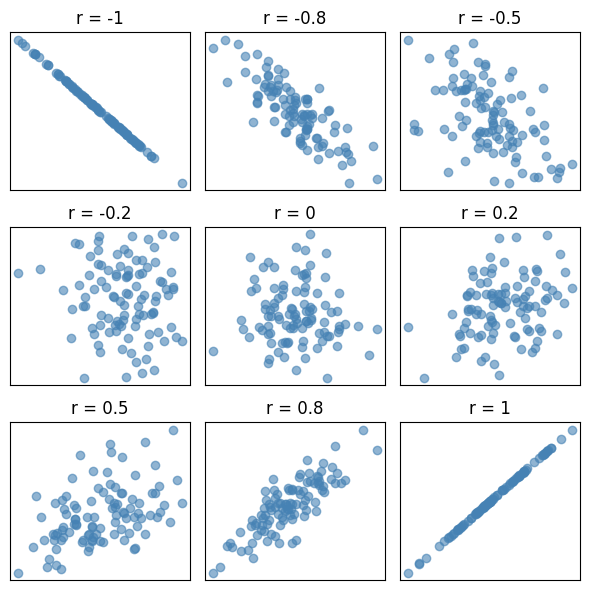

In [48]:
# 다음은 몇가지 상관계수에 대응하는 산점도입니다.

import numpy as np
import matplotlib.pyplot as plt

# 랜덤 시드 고정
np.random.seed(0)

# 원하는 상관계수 값들
r_values = [-1, -0.8, -0.5, -0.2, 0, 0.2, 0.5, 0.8, 1]

# 데이터 개수
n = 100

# 3x3 subplot 준비
fig = plt.figure(figsize=(6, 6))

for i, r in enumerate(r_values):
    # 공분산 행렬 구성
    cov = [[1, r],
           [r, 1]]

    # 다변량 정규분포 샘플 생성 (평균 0, 분산 1, 상관 r)
    data = np.random.multivariate_normal([0, 0], cov, size=n)
    x, y = data.T

    ax = fig.add_subplot(3, 3, i+1)
    ax.scatter(x, y, alpha=0.6, color="steelblue")
    ax.set_title(f"r = {r}")
    ax.set_xticks([])
    ax.set_yticks([])


plt.tight_layout()
plt.show()

In [49]:
# p.77에서 상관계수와 관련된 산점도를 확인할 수 있습니다.
# 영어점수와 수학점수의 상관계수를 계산해봅시다.
np.cov(en_scores, ma_scores, ddof=0)[0, 1] / (np.std(en_scores) * np.std(ma_scores))

np.float64(0.8185692341186713)

In [51]:
# numpy에서는 corrcoef함수를 제공합니다.
# correlation(상관관계) + coefficient(계수)
# 반환값은 cov와 마찬가지로 Scalar가 아니라 행렬입니다. (상관행렬)
np.corrcoef(en_scores, ma_scores)

array([[1.   , 0.819],
       [0.819, 1.   ]])

In [52]:
# pandas의 경우 corr함수를 제공합니다.
scores_df.corr()

,english,mathematics
english,1.000,0.819
mathematics,0.819,1.000


## 2차원 데이터의 시각화
* 산점도
* 회귀직선
* 히트맵 (히스토그램의 2차원버전)

### 산점도

In [ ]:
# 시각화를 위한 package인 matplotlib를 import 해줍니다.
import matplotlib.pyplot as plt

%matplotlib inline

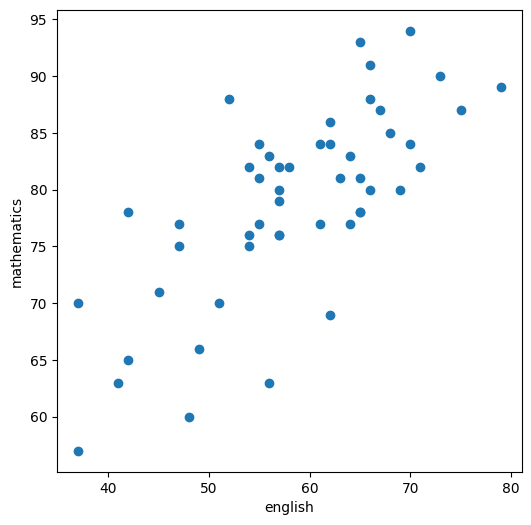

In [53]:
# 이번에는 10개 데이터 뿐만 아니라, 전체데이터를 시각화해봅시다.
# 위의 산점도 중 r=0.8의 산점도와 상당히 비슷한 모습을 확인할 수 있습니다.

english_scores = np.array(df['english'])
math_scores = np.array(df['mathematics'])

# 그림판 준비하기.
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

# 산점도 그리기
ax.scatter(english_scores, math_scores)

ax.set_xlabel('english')
ax.set_ylabel('mathematics')

# 산점도 보여주기
plt.show()

### 회귀직선

In [ ]:
# 회귀직선은 두 데이터 사이의 관계를 나타내는 직선형태의 함수입니다.
display(Math(r"y = β_0 + β_1 x"))

<IPython.core.display.Math object>

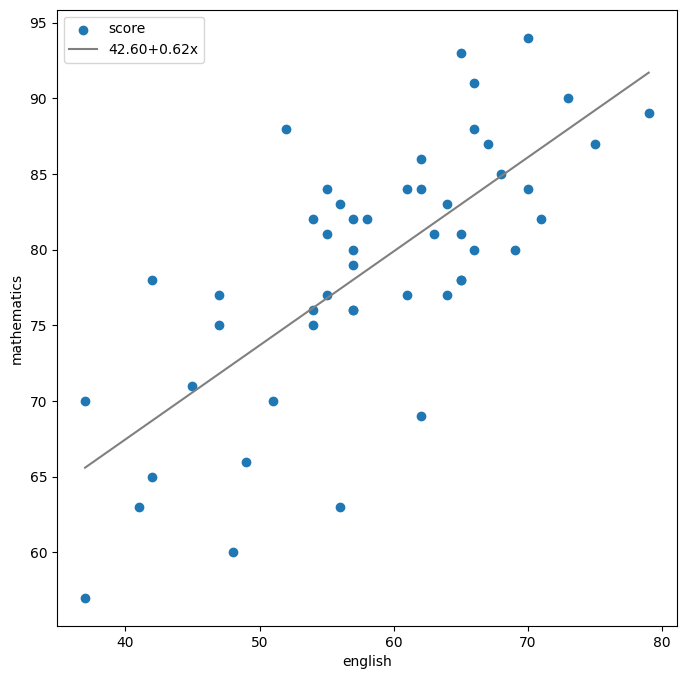

In [54]:


# 회귀계수 β₀(절편), β₁(기울기)를 최소제곱법으로 구한다
# polyfit(x, y, 차수) → [β₁, β₀] (차수가 1이면 1차 직선)
poly_fit = np.polyfit(english_scores, math_scores, 1)

# β₀ + β₁x 형태의 일차 함수를 poly1d 객체로 만든다
# poly_1d(x)를 호출하면 y 예측값을 얻을 수 있다
poly_1d = np.poly1d(poly_fit)

# 직선을 그리기 위해 x좌표를 생성
xs = np.linspace(english_scores.min(), english_scores.max())

# 만들어진 x 좌표(xs)에 대응하는 y 좌표(수학 점수 예측값)를 계산
ys = poly_1d(xs)

# --- 시각화 영역 ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)
ax.set_xlabel('english')
ax.set_ylabel('mathematics')

# 산점도: 실제 데이터 점들을 표시
ax.scatter(english_scores, math_scores, label='score')

# 회귀직선: 계산된 회귀식을 직선으로 표시
# f-string으로 '절편 + 기울기·x' 형태의 식도 범례에 표시해줍니다.
ax.plot(xs, ys, color='gray', label=f'{poly_fit[1]:.2f}+{poly_fit[0]:.2f}x')

# 범례(legend)를 왼쪽 위에 표시
ax.legend(loc='upper left')

plt.show()

### 히트맵

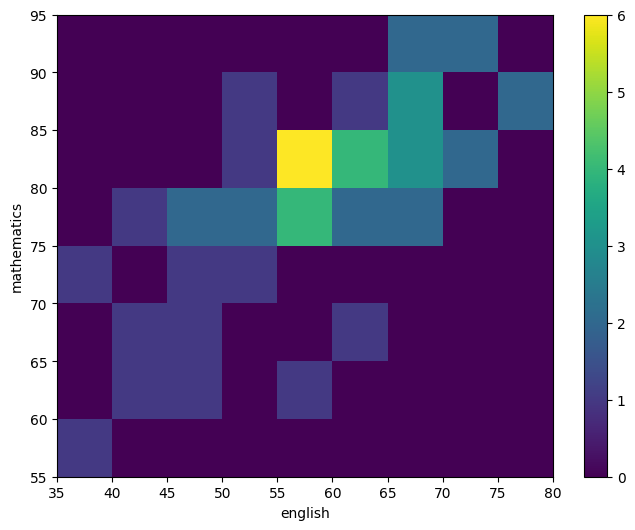

In [55]:
# 1차원 데이터 정리에서 배웠던 영어점수에 대한 도수(frequency)를 높이로 시각화 했던 히스토그램이 기억 나시죠?
# 히트맵은 영어점수와 수학점수에 대한 도수(frequency)를 색상으로 시각화한것입니다.

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

c = ax.hist2d(english_scores, math_scores, bins=[9, 8], range=[(35, 80), (55, 95)])
ax.set_xlabel('english')
ax.set_ylabel('mathematics')
ax.set_xticks(c[1])
ax.set_yticks(c[2])
# 컬러 바의 표시
fig.colorbar(c[3], ax=ax)
plt.show()

## 앤스컴의 예 (부제: 시각화의 필요성)

In [56]:
# 2장과 3장에서는 데이터의 특징을 파악하기 위해 데이터 요약을 수행하고, 해당 지표를 통해 분석하는 방법을 배웠습니다.
# 그러나 이렇게 수치로 데이터를 요약하다보면 많은 정보를 잃어버릴 수 있으니 주의해야합니다.
# 지표상 동일한 수치를 갖고 있지만, 시각화를 해보면 전혀 다른 데이터가되는 경우가 있습니다.

# 프란시스 앤스컴이라는 통계학자가 만든 데이터
# 지표가 같지만, 시각화하면 전혀 다른 데이터

anscombe_data = np.load('ch3_anscombe.npy')
print(anscombe_data.shape)
anscombe_data[0]

(4, 11, 2)


array([[10.  ,  8.04],
       [ 8.  ,  6.95],
       [13.  ,  7.58],
       [ 9.  ,  8.81],
       [11.  ,  8.33],
       [14.  ,  9.96],
       [ 6.  ,  7.24],
       [ 4.  ,  4.26],
       [12.  , 10.84],
       [ 7.  ,  4.82],
       [ 5.  ,  5.68]])

In [58]:
# 각 데이터의 평균, 분산, 상관계수, 회귀직선을 계산하여 DataFrame으로 예쁘게 만듭니다.
# 모든 데이터가 평균부터 회귀직선식까지 전부 일치하는 것을 확인할 수 있습니다.
stats_df = pd.DataFrame(index=['X_mean',      'X_variance',       'Y_mean',
                               'Y_variance',  'X&Y_correlation',  'X&Y_regression line'])
for i, data in enumerate(anscombe_data):
    dataX = data[:, 0]
    dataY = data[:, 1]
    poly_fit = np.polyfit(dataX, dataY, 1)
    stats_df[f'data{i+1}'] =\
        [f'{np.mean(dataX):.2f}',
         f'{np.var(dataX):.2f}',
         f'{np.mean(dataY):.2f}',
         f'{np.var(dataY):.2f}',
         f'{np.corrcoef(dataX, dataY)[0, 1]:.2f}',
         f'{poly_fit[1]:.2f}+{poly_fit[0]:.2f}x']
stats_df

,data1,data2,data3,data4
X_mean,9.00,9.00,9.00,9.00
X_variance,10.00,10.00,10.00,10.00
Y_mean,7.50,7.50,7.50,7.50
Y_variance,3.75,3.75,3.75,3.75
X&Y_correlation,0.82,0.82,0.82,0.82
X&Y_regression line,3.00+0.50x,3.00+0.50x,3.00+0.50x,3.00+0.50x


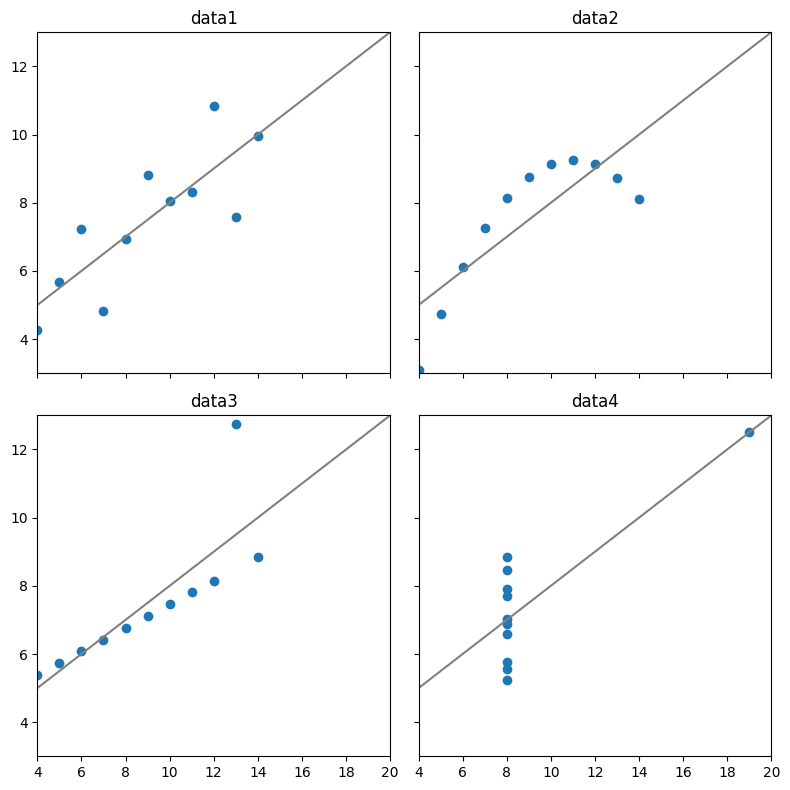

In [59]:
# 이 4가지 데이터가 동일한지 시각화를 해봅니다.

# 그래프를 그리기 위한 영역을 2x2개 생성
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8),
                         sharex=True, sharey=True)

xs = np.linspace(0, 30, 100)
for i, data in enumerate(anscombe_data):
    poly_fit = np.polyfit(data[:,0], data[:,1], 1)
    poly_1d = np.poly1d(poly_fit)
    ys = poly_1d(xs)
    # 그리는 영역을 선택
    ax = axes[i//2, i%2]
    ax.set_xlim([4, 20])
    ax.set_ylim([3, 13])
    # 타이틀을 부여
    ax.set_title(f'data{i+1}')
    ax.scatter(data[:,0], data[:,1])
    ax.plot(xs, ys, color='gray')

# 그래프 사이의 간격을 좁힘
plt.tight_layout()
plt.show()

### 수업내용 프린트하기

In [ ]:
# 1) 필수 설치
!pip install -q "nbconvert[webpdf]" playwright

# 2) Playwright용 Chromium 설치 (리눅스 의존성도 같이)
!python -m playwright install --with-deps chromium

# 3) (한글 폰트 깨짐 방지, 선택) Noto CJK 설치
!apt-get -y update && apt-get -y install fonts-noto-cjk

# 4) PDF 변환 (실행번호 포함하도록 프롬프트 표시 옵션 유지)
!jupyter nbconvert --to webpdf \
  --TemplateExporter.exclude_input_prompt=False \
  --TemplateExporter.exclude_output_prompt=False \
  ../notebook/chap03.ipynb